# LoanShield: Final Model Visualization
In this notebook, we load the tuned model and generate comprehensive visualizations to evaluate its performance.

**Key Visualizations:**
1. **Confusion Matrix:** Where is the model making mistakes?
2. **ROC Curve:** How well does it distinguish between Default/Non-Default?
3. **Precision-Recall Curve:** Critical for imbalanced datasets.
4. **Feature Importance:** Which factors (Income, Age, etc.) matter most?
5. **Probability Distribution:** How confident is the model?

In [12]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, classification_report

# Configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 6)

In [13]:
# 2. Load Data and Model
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.flatten()

# Load the best model saved in Week 5
model = joblib.load('../webapp/models/best_model.pkl')

print("✅ Data and Model Loaded Successfully.")

# Generate Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # Probability of Default (1)

✅ Data and Model Loaded Successfully.


## Part 1: Confusion Matrix
This shows the raw count of:
- **True Negatives:** Correctly predicted "No Default".
- **False Positives:** Incorrectly predicted "Default" (False Alarm).
- **False Negatives:** Incorrectly predicted "No Default" (Missed Risk).
- **True Positives:** Correctly predicted "Default".

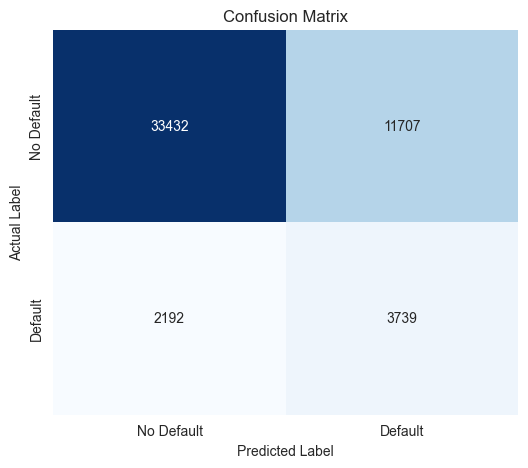

              precision    recall  f1-score   support

           0       0.94      0.74      0.83     45139
           1       0.24      0.63      0.35      5931

    accuracy                           0.73     51070
   macro avg       0.59      0.69      0.59     51070
weighted avg       0.86      0.73      0.77     51070



In [14]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

# Print detailed text report
print(classification_report(y_test, y_pred))

## Part 2: ROC Curve (Receiver Operating Characteristic)
The ROC curve plots the **True Positive Rate** against the **False Positive Rate**.
- A curve closer to the **top-left corner** is better.
- **AUC (Area Under Curve)**: 1.0 is perfect, 0.5 is random guessing.

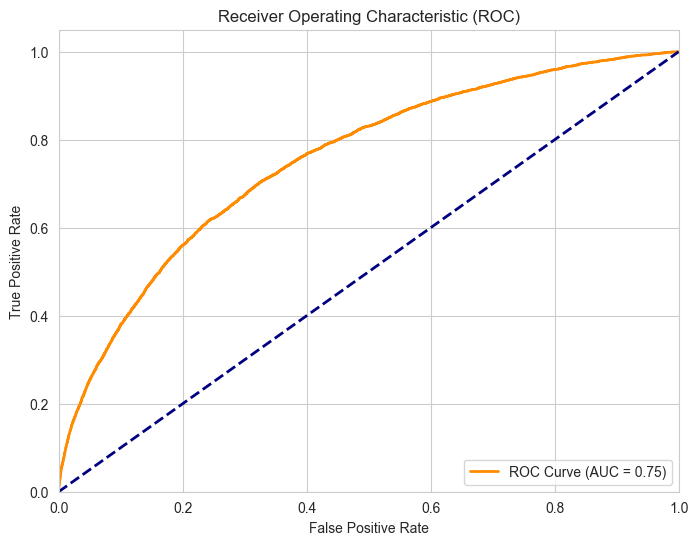

In [15]:
# Calculate ROC metrics
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

## Part 3: Precision-Recall Curve
Since our dataset is imbalanced (fewer defaulters), the PR Curve is often more informative than ROC.
It shows the trade-off between **Precision** (Accuracy of positive predictions) and **Recall** (Ability to find all positives).

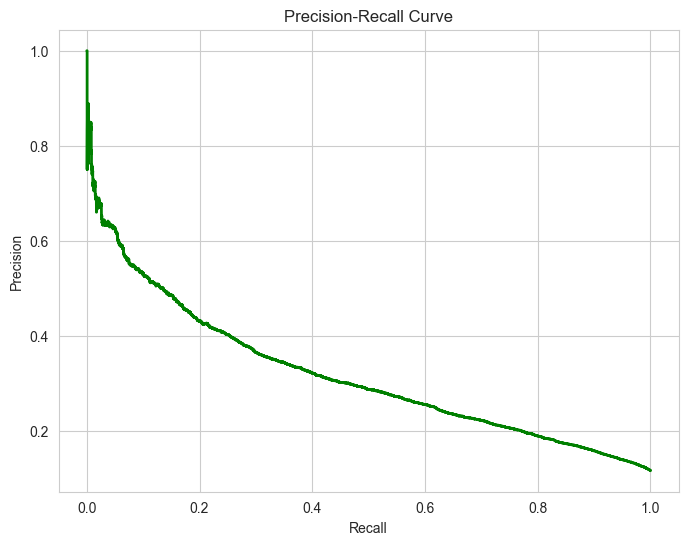

In [16]:
# Calculate PR metrics
precision, recall, _ = precision_recall_curve(y_test, y_prob)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

## Part 4: Feature Importance
This is one of the most important plots. It tells us **what drives the decision**.
Does Income matter more? Or Credit Score? Or Age?

C:\Users\DHAVAL TALAVIYA\AppData\Local\Temp\ipykernel_1588\358719714.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


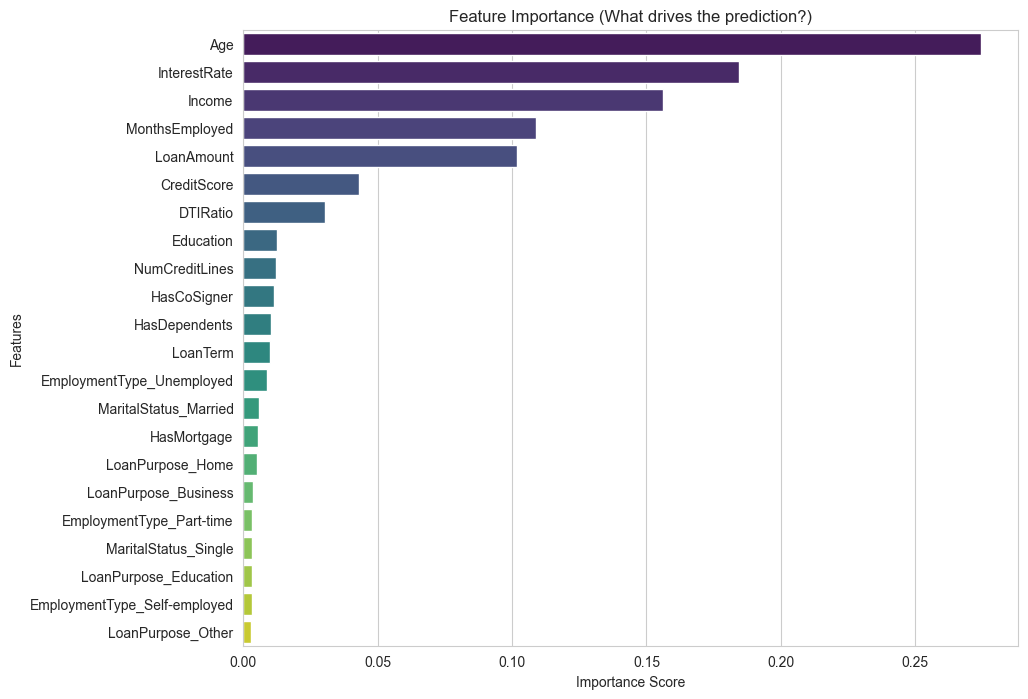

In [17]:
# Extract Feature Importance
importances = model.feature_importances_
feature_names = X_test.columns

# Create a DataFrame
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title('Feature Importance (What drives the prediction?)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

## Part 5: Prediction Probability Distribution
This histogram shows how confident the model is.
- **Red:** Actual Defaulters (Should have high probability).
- **Blue:** Non-Defaulters (Should have low probability).
A good model separates these two distributions clearly.

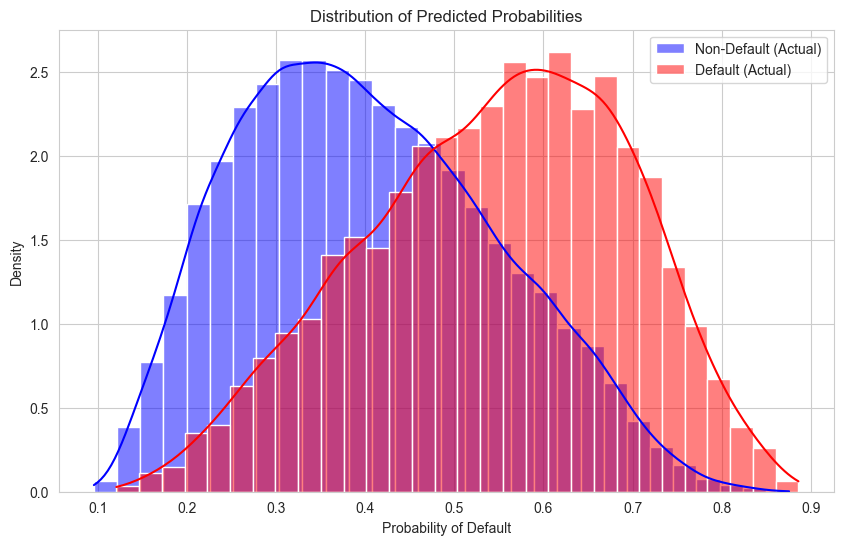

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(y_prob[y_test == 0], color='blue', label='Non-Default (Actual)', kde=True, stat="density", bins=30, alpha=0.5)
sns.histplot(y_prob[y_test == 1], color='red', label='Default (Actual)', kde=True, stat="density", bins=30, alpha=0.5)
plt.title('Distribution of Predicted Probabilities')
plt.xlabel('Probability of Default')
plt.ylabel('Density')
plt.legend()
plt.show()